In [1]:
import os
from pathlib import Path

def root_dir(marker="EXPLib"):
    cwd = Path.cwd()
    # if cwd already contains the marker
    if (cwd / marker).is_dir():
        return cwd
    # otherwise walk up the parents
    for p in cwd.parents:
        if (p / marker).is_dir():
            return p
    raise FileNotFoundError(f"Root marker '{marker}' not found")

os.chdir(root_dir())
#print(os.getcwd())

In [2]:
import torch

from EXPLib.xai_library.model_explainers.model_utils.toymodel_utils import preprocess_image
from EXPLib.xai_library.model_explainers.uncertainty_models.toymodel_ssd_aleatoric_unc import ssd_alea_unc_utils


image_path = './EXPLib/datasets/Camera/toy_model_v1_inference/dev/images'
image_file = 'rgb_0000079.png'
weight_path = './EXPLib/dl_component/CNN/Object_Detectors/toy_model_v1'
weight_file = 'ssd_model_with_uncertainty_epoch_70'
model_name = "ssdlite320_mobilenet_v3_large"
num_classes = 2

############################################################################
# Check if a GPU is available and if not, use a CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Define the model with uncertainty
model = ssd_alea_unc_utils.ssdlite320_mobilenet_v3_large_unc(num_classes=2, pretrained=True, weights_name=os.path.join(weight_path, weight_file)) 
res=model.to(device).eval()

In [4]:
image = preprocess_image(image_path, image_file, device)
prediction = model(image)

In [5]:
print("Bounding box uncertainties: ", prediction[0]['bbox_uncertainty'][0])
print("Bounding box prediction: ", prediction[0]['boxes'][0])

Bounding box uncertainties:  tensor([-0.0908,  0.2567,  0.0729,  0.4461], device='cuda:0',
       grad_fn=<SelectBackward0>)
Bounding box prediction:  tensor([ 40.1028,  69.7285, 233.4143, 281.3538], device='cuda:0',
       grad_fn=<SelectBackward0>)


CI95 Bounding Boxes: ([41.975772857666016, 71.95689392089844, 231.3814697265625, 278.90411376953125], [38.229732513427734, 67.50004577636719, 235.44708251953125, 283.80352783203125])


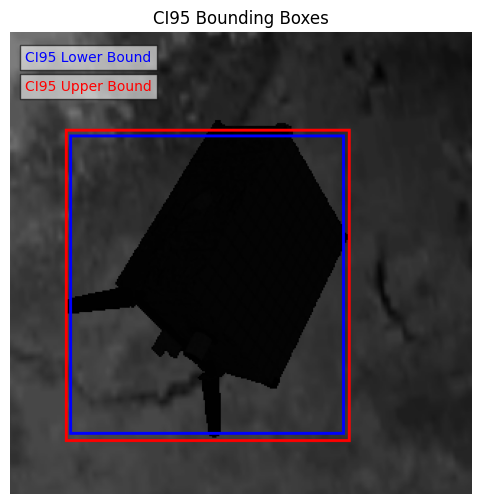

In [6]:
ssd_alea_unc_utils.visualize_max_score_bbox(
    prediction,
    image,
    ssd_alea_unc_utils,
    threshold=0.5,
    save_output=False,   # change to False to skip saving
    output_path="ci95_output.png"
)